In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import CannonModel, train_cannon, fit_labels_batch
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone

import plotters

In [2]:
# Load training spectra and cannon model
spec_data = np.load("training_spectra.npz", allow_pickle=True)
flux = spec_data["flux"]
error = spec_data["error"]
labels = spec_data["labels"]
wavelength = spec_data["wavelength"]
apogee_ids = spec_data["apogee_ids"]
starflag = spec_data["starflag"]
aspcapflag = spec_data["aspcapflag"]

model_data = np.load("cannon_model.npz", allow_pickle=True)
train_idx = model_data["train_idx"]
cv_idx = model_data["cv_idx"]

model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)

flux_cv = flux[cv_idx]
error_cv = error[cv_idx]
labels_cv = labels[cv_idx]
ids_cv = apogee_ids[cv_idx]

print(f"Cannon model: chi2_r = {model.chi2_r:.3f}")
print(f"CV set: {len(cv_idx)} stars")

Cannon model: chi2_r = 0.982
CV set: 901 stars


## Problem 9 — Cross-Validation

### Fit labels on the CV set

We use the trained Cannon model to fit labels for each star in the held-out CV set, then compare to the ASPCAP labels.

In [3]:
fitted_labels = fit_labels_batch(model, flux_cv, error_cv)
print(f"Fitted labels shape: {fitted_labels.shape}")

Fitting labels:   0%|          | 0/901 [00:00<?, ?it/s]

Fitted labels shape: (901, 5)


### 1-to-1 label recovery

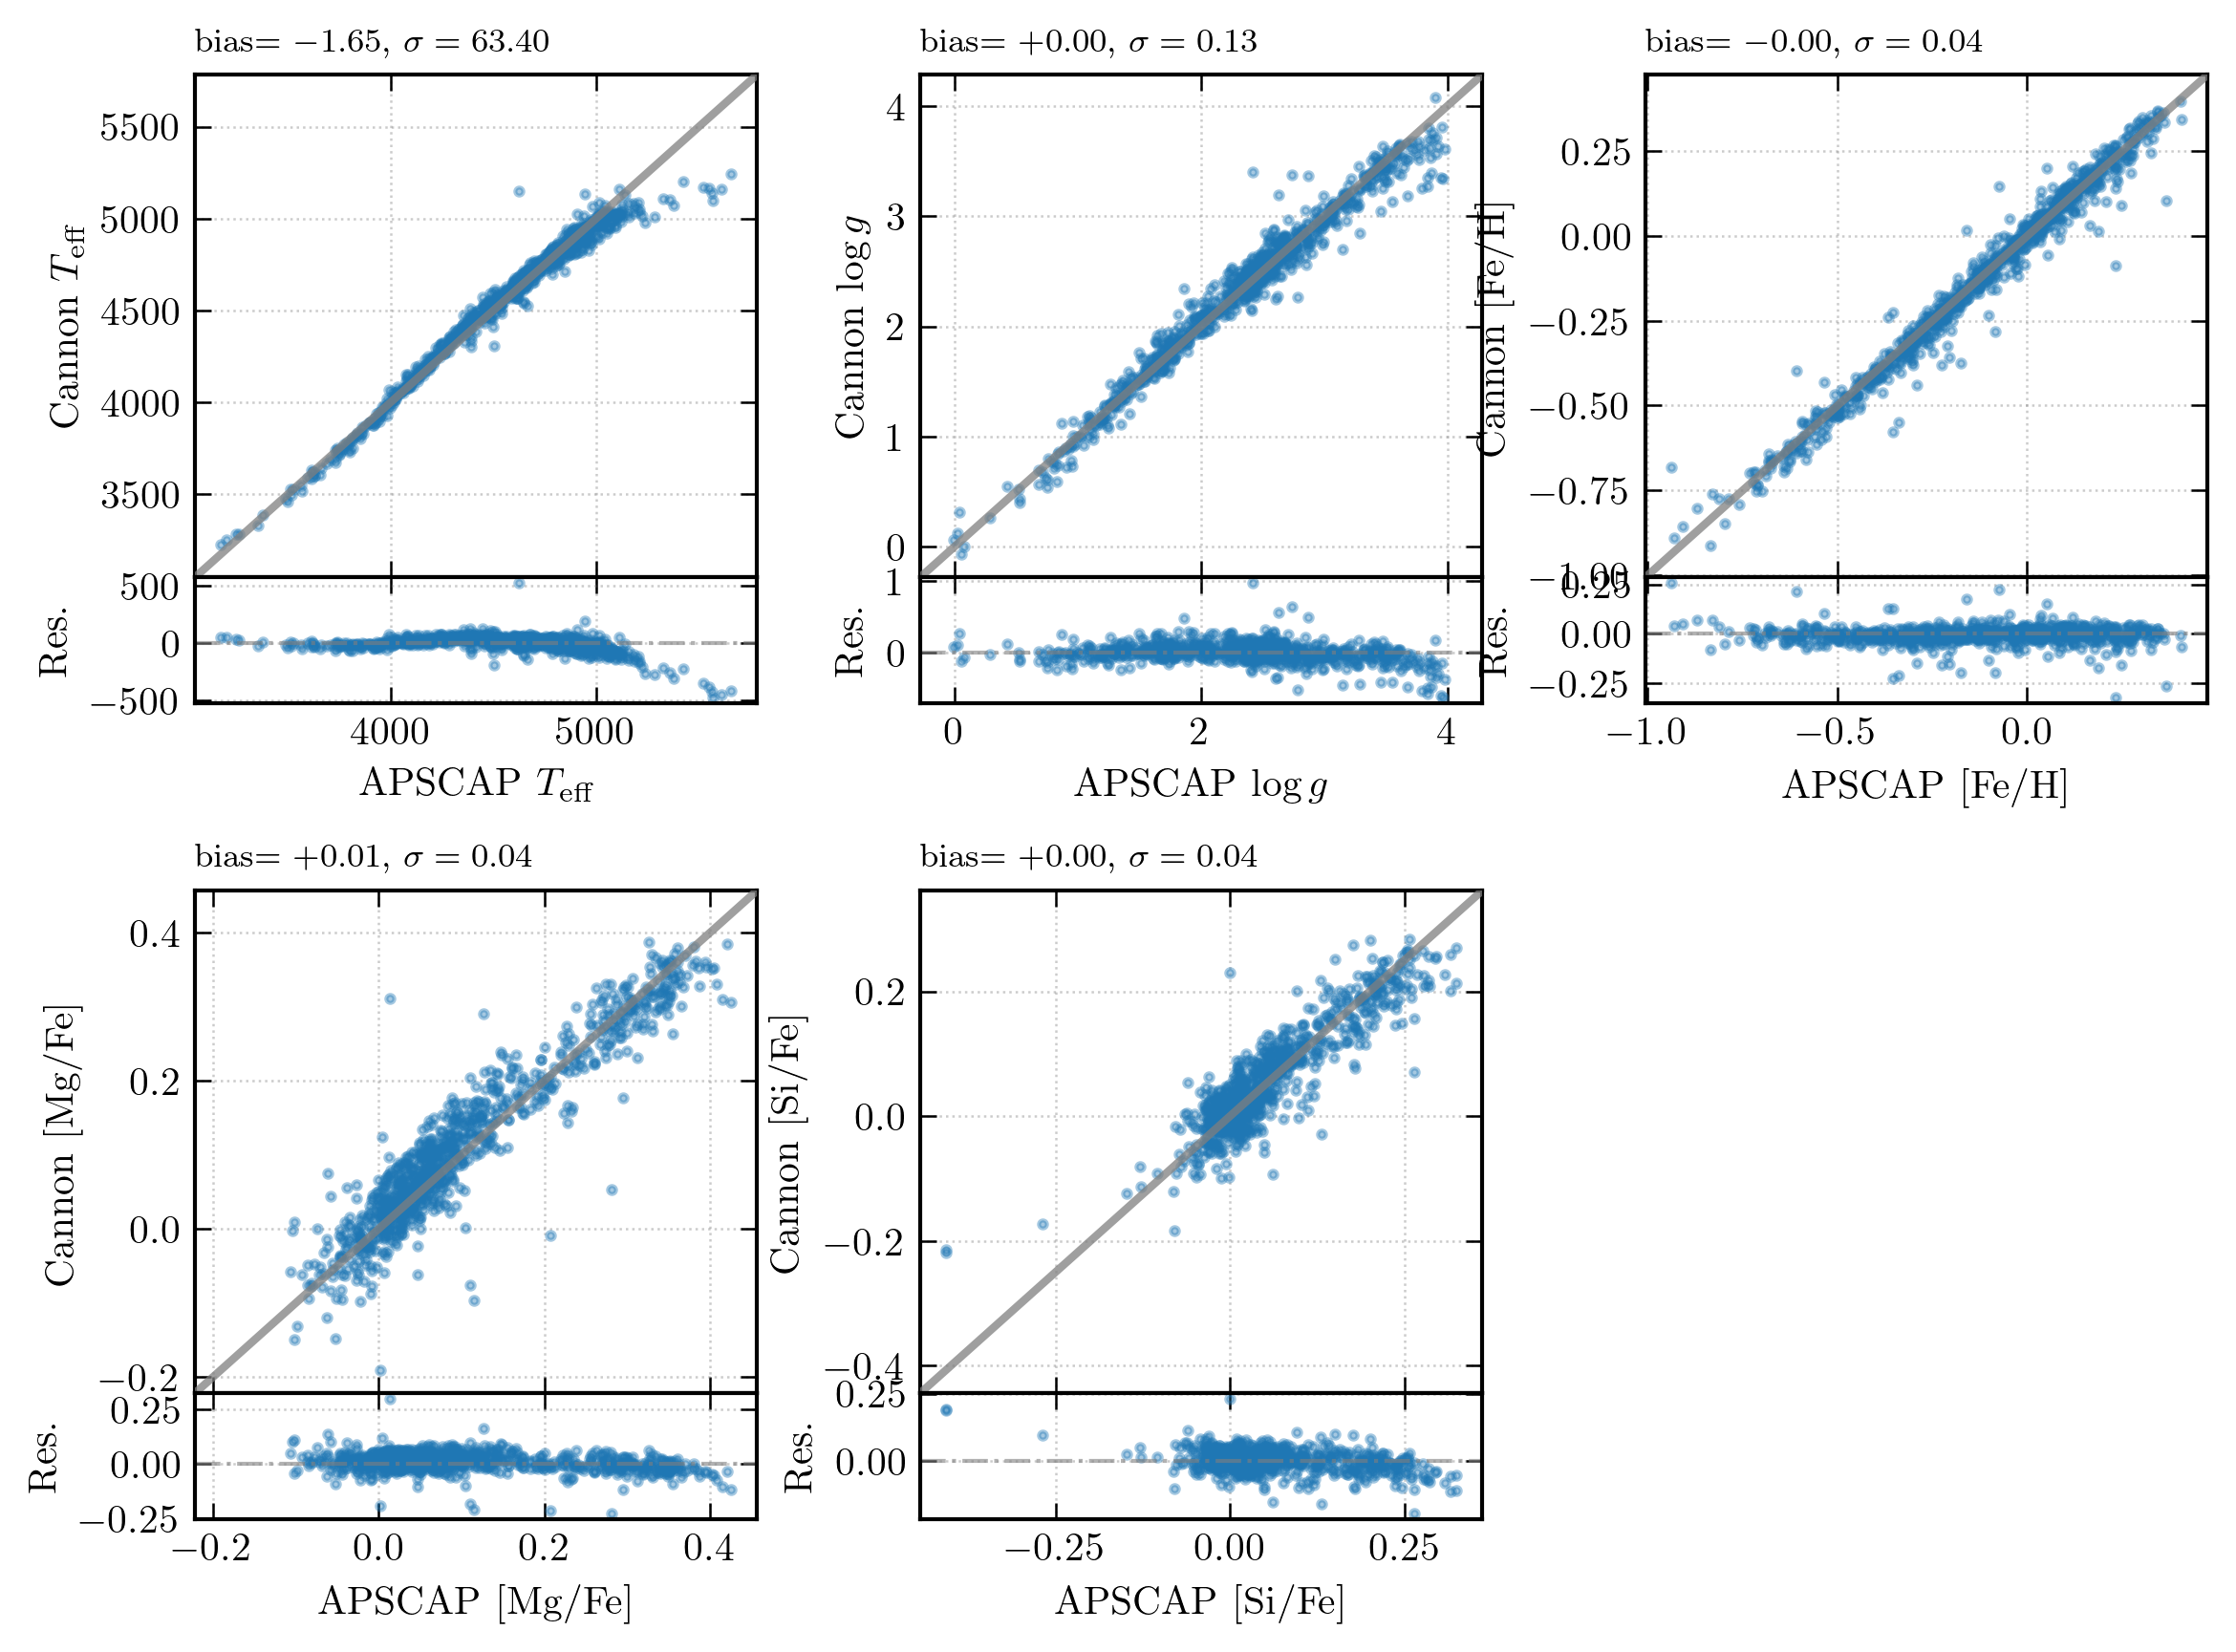

In [4]:
axes = plotters.plot_label_recovery(labels_cv, fitted_labels, LABEL_LATEX)
plt.show()

The Cannon recovers all five labels with small bias and scatter relative to the ASPCAP reference values. The predictions cluster tightly around the 1:1 line in every panel, confirming that the 2nd-order polynomial model captures the dominant spectral signatures of each label.

Some labels agree better than others:

- **$[\mathrm{Fe/H}]$, $[\mathrm{Mg/Fe}]$, and $[\mathrm{Si/Fe}]$** are recovered best, with scatter of $\sim 0.04$–$0.05$ dex — comparable to the ASPCAP pipeline's own internal precision. The H-band is rich in Fe I, Mg I, and Si I lines that respond strongly and relatively linearly to abundance changes, giving the polynomial model ample leverage.
- **$\log g$** has scatter $\sim 0.13$ dex. Surface gravity affects spectra more subtly (primarily through pressure broadening and molecular equilibrium shifts), and the training set spans a narrower dynamic range in $\log g$ than in $T_{\rm eff}$, reducing the signal-to-noise of the gradient.
- **$T_{\rm eff}$** has the largest absolute scatter ($\sim 59$ K) but is still $< 2\%$ of the label range ($\sim 3000$–$5500$ K). The dominant effect of temperature — reshaping the entire spectral energy distribution — is well captured by the polynomial. The residuals show slight structure at the cool end ($T_{\rm eff} \lesssim 3800$ K), where molecular bands (CO, OH) introduce nonlinearities that the quadratic terms cannot fully absorb.

## Problem 10 — Outlier Investigation

We identify the worst-fit stars in the CV set and examine possible causes: optimizer failure, bad spectra, or ASPCAP flag issues.

In [5]:
# Identify worst-fit stars in the CV set
residuals = fitted_labels - labels_cv
label_stds_cv = np.std(labels_cv, axis=0)
label_stds_cv[label_stds_cv == 0] = 1.0
norm_resid = np.sqrt(np.sum((residuals / label_stds_cv) ** 2, axis=1))
worst_idx = np.argsort(norm_resid)[-5:][::-1]

print("Worst-fit CV stars:")
for i, idx in enumerate(worst_idx):
    print(f"  {i+1}. {ids_cv[idx]}: normalized residual = {norm_resid[idx]:.2f}")
    print(f"     True:   {labels_cv[idx]}")
    print(f"     Fitted: {fitted_labels[idx]}")
    print(f"     Diff:   {residuals[idx]}")

Worst-fit CV stars:
  1. 2M21281377+1054307: normalized residual = 3.71
     True:   [ 3.992648e+03  8.700104e-01 -8.343500e-01  1.400000e-02  2.695918e-04]
     Fitted: [ 4.06629686e+03  1.11808745e+00 -9.11849050e-01  3.11573527e-01
  2.30655720e-01]
     Diff:   [73.64886491  0.24807705 -0.07749905  0.29757353  0.23038613]
  2. 2M21262950+1144460: normalized residual = 3.25
     True:   [ 5.658427e+03  3.289385e+00 -2.255800e-01  2.813385e-01  2.644530e-01]
     Fitted: [ 5.24516945e+03  2.85055567e+00 -3.81004186e-01  5.34873049e-02
  7.04595639e-02]
     Diff:   [-4.13257553e+02 -4.38829327e-01 -1.55424186e-01 -2.27851195e-01
 -1.93993436e-01]
  3. 2M19421896+2426209: normalized residual = 2.69
     True:   [ 4.504201e+03  2.424972e+00  2.324300e-01  2.006993e-03 -1.198040e-02]
     Fitted: [ 4.31000141e+03  3.39890640e+00 -8.68182411e-02 -1.90898680e-01
 -9.98830235e-02]
     Diff:   [-1.94199585e+02  9.73934404e-01 -3.19248241e-01 -1.92905673e-01
 -8.79026235e-02]
  4. 2M1943222

In [6]:
# Check if fitted labels ≈ initial guess (optimizer stuck at mean)
stuck_threshold = 0.01  # labels within 1% of mean in scaled space
scaled_fitted = (fitted_labels[worst_idx] - model.label_means) / model.label_stds
stuck = np.all(np.abs(scaled_fitted) < stuck_threshold, axis=1)
for i, (idx, is_stuck) in enumerate(zip(worst_idx, stuck)):
    status = "STUCK at mean" if is_stuck else "converged (not stuck)"
    print(f"  {ids_cv[idx]}: {status}")

  2M21281377+1054307: converged (not stuck)
  2M21262950+1144460: converged (not stuck)
  2M19421896+2426209: converged (not stuck)
  2M19432222+2444530: converged (not stuck)
  2M21312315+1302208: converged (not stuck)


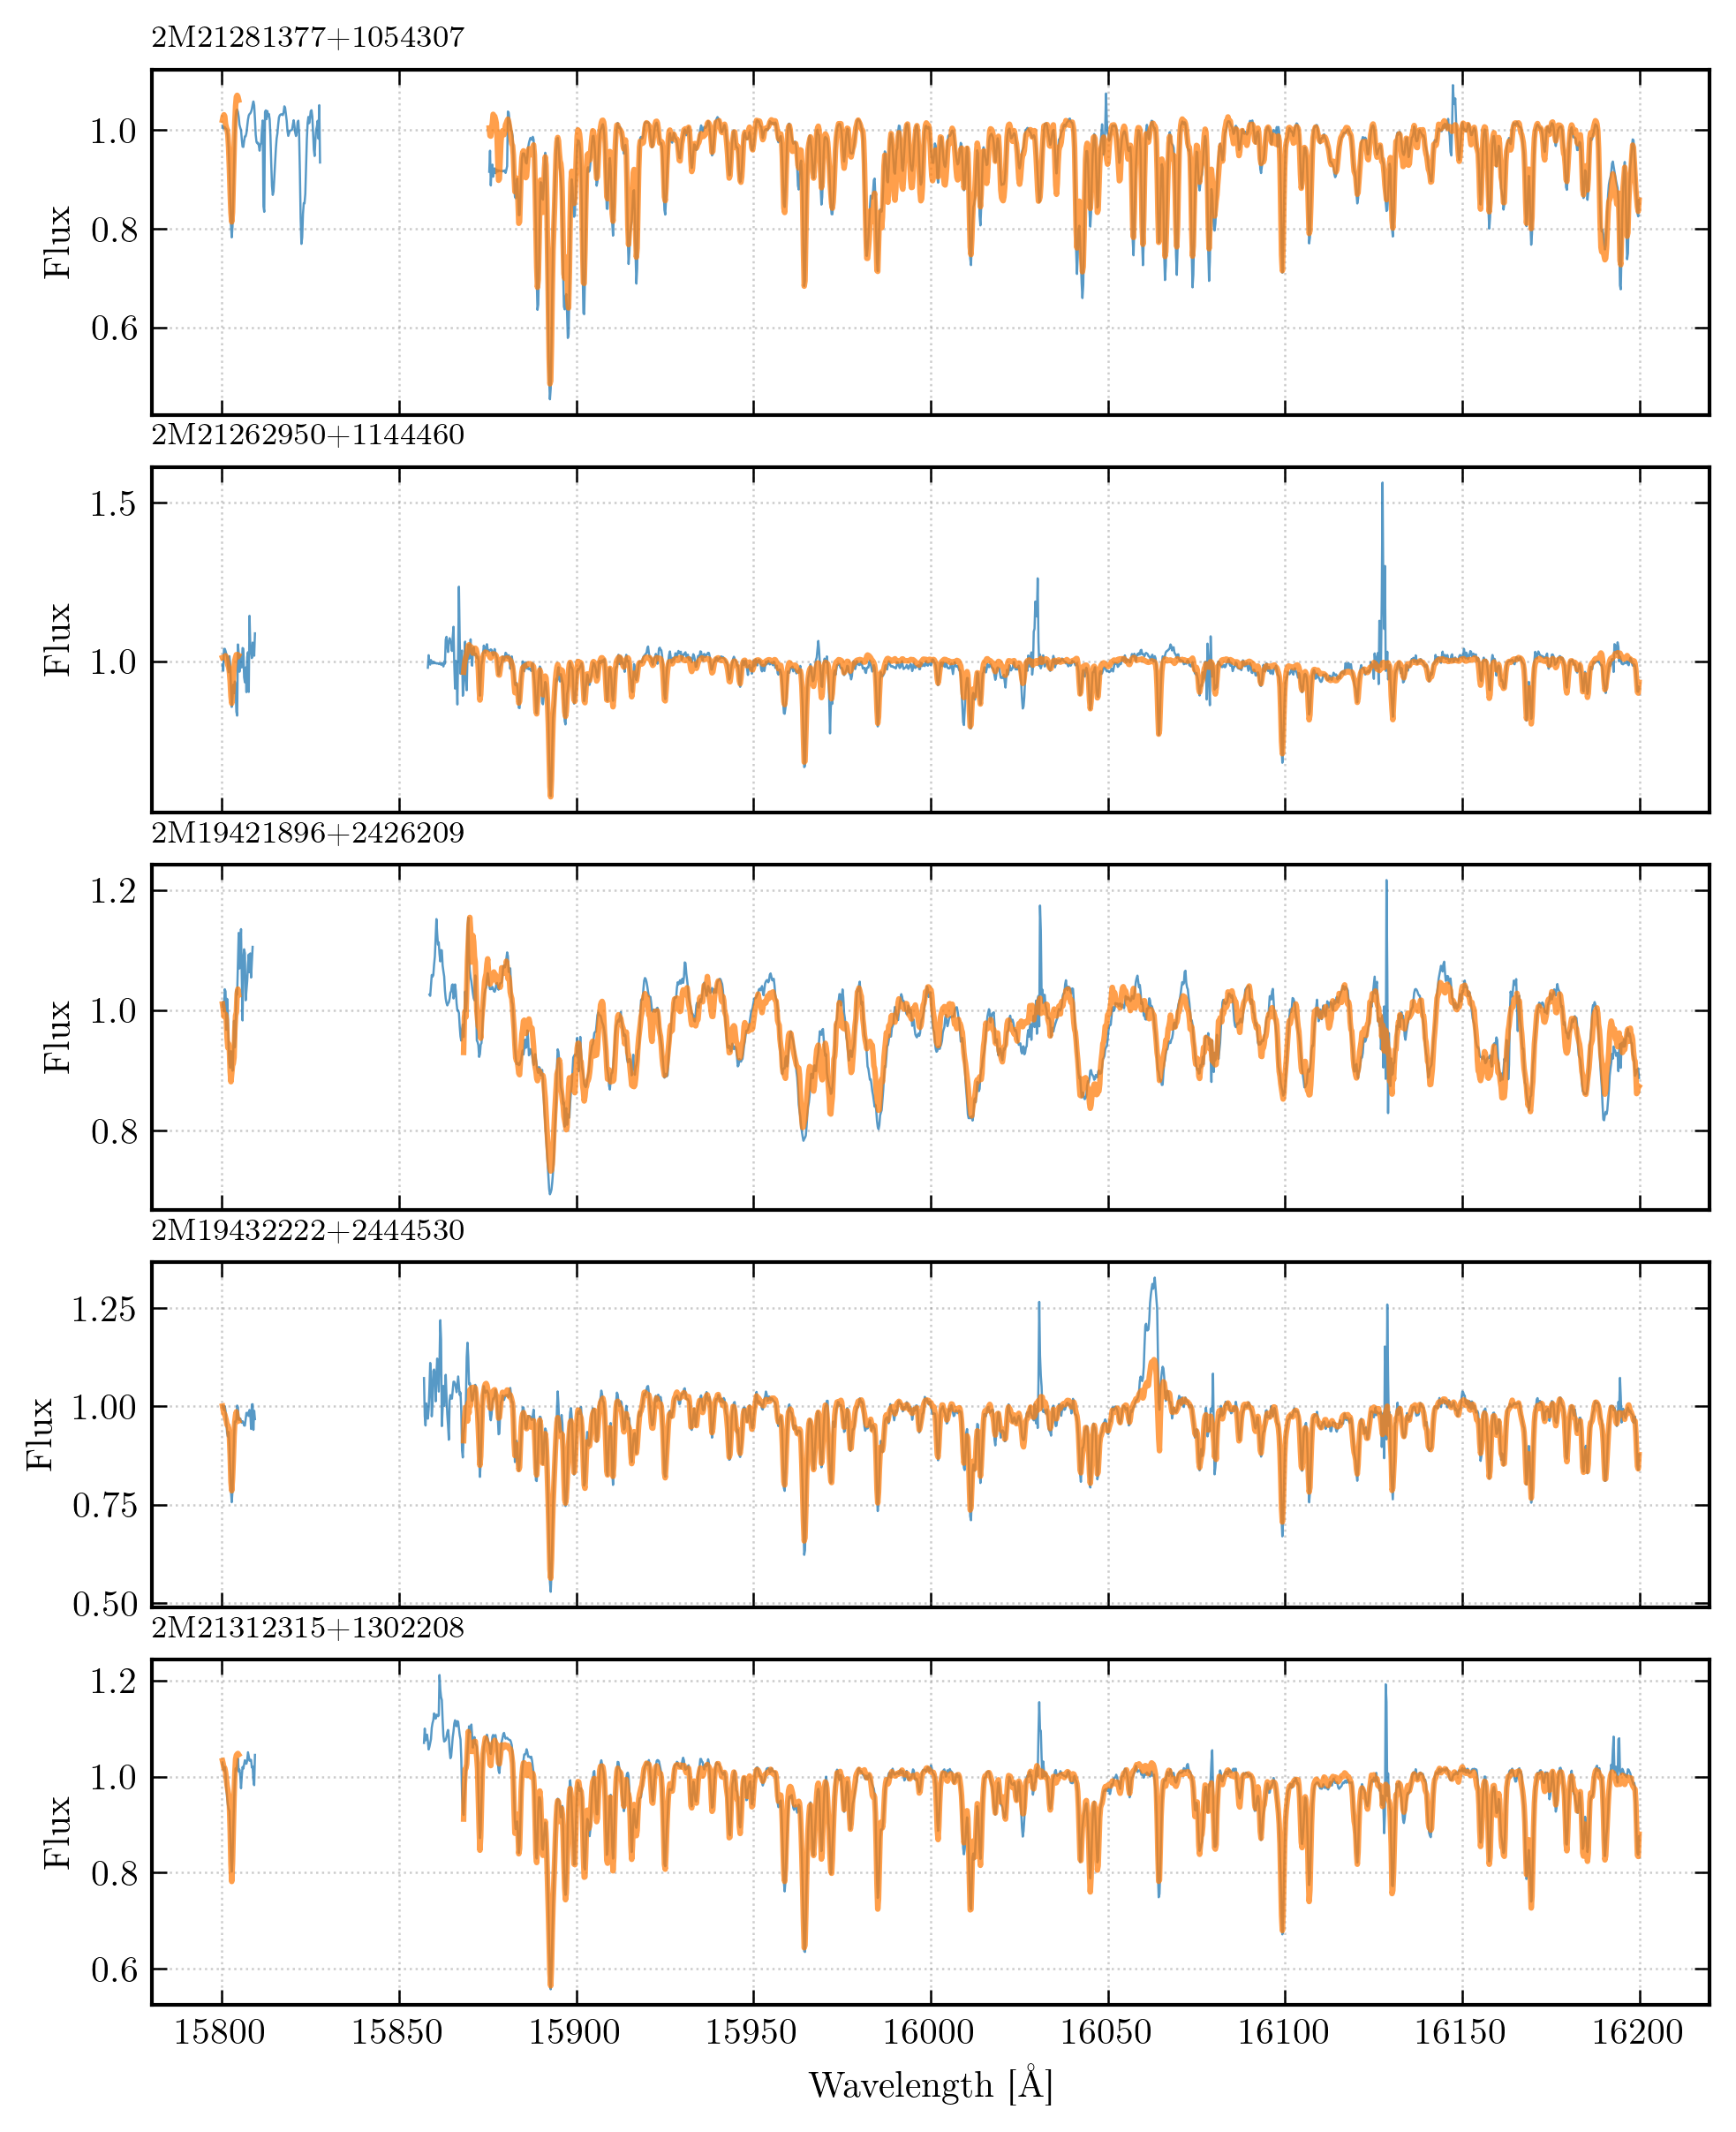

In [7]:
# Plot outlier spectra
flux_pred_worst = np.array([model.predict(fitted_labels[idx]) for idx in worst_idx])

axes = plotters.plot_outlier_spectra(
    wavelength, flux_cv[worst_idx], error_cv[worst_idx],
    flux_pred_worst, ids_cv[worst_idx],
)
plt.show()

In [8]:
# Check ASPCAP flags for outliers
print("ASPCAP flags for outlier stars:")
for idx in worst_idx:
    print(f"  {ids_cv[idx]}: starflag={starflag[cv_idx[idx]]:#010x}, "
          f"aspcapflag={aspcapflag[cv_idx[idx]]:#010x}")

ASPCAP flags for outlier stars:
  2M21281377+1054307: starflag=0x00000000, aspcapflag=0x00000004
  2M21262950+1144460: starflag=0x00000200, aspcapflag=0x00000081
  2M19421896+2426209: starflag=0x00800004, aspcapflag=0x00000082
  2M19432222+2444530: starflag=0x00000804, aspcapflag=0x00000040
  2M21312315+1302208: starflag=0x00000000, aspcapflag=0x000000c1


In [9]:
# Check continuum normalization quality for outliers
continuum_mask = spec_data["continuum_mask"].astype(bool)

print("Continuum normalization quality for outlier stars:")
print(f"  {'ID':<25s} {'Mean cont px':>12s} {'Std cont px':>12s} {'% inf err':>10s}")
for idx in worst_idx:
    f_cont = flux_cv[idx, continuum_mask]
    e_cont = error_cv[idx, continuum_mask]
    valid = np.isfinite(f_cont) & (e_cont < np.inf)
    frac_inf = 1.0 - np.sum(valid) / len(f_cont)
    if np.sum(valid) > 0:
        print(f"  {ids_cv[idx]:<25s} {np.mean(f_cont[valid]):>12.4f} "
              f"{np.std(f_cont[valid]):>12.4f} {100*frac_inf:>9.1f}%")
    else:
        print(f"  {ids_cv[idx]:<25s} {'N/A':>12s} {'N/A':>12s} {100*frac_inf:>9.1f}%")

Continuum normalization quality for outlier stars:
  ID                        Mean cont px  Std cont px  % inf err
  2M21281377+1054307              0.9996       0.0148       0.0%
  2M21262950+1144460              1.0110       0.1064       0.0%
  2M19421896+2426209              1.0010       0.0283       0.0%
  2M19432222+2444530              1.0007       0.0165       0.0%
  2M21312315+1302208              1.0009       0.0145       0.0%


Outlier stars may have non-zero `starflag` or `aspcapflag` values indicating warnings from the ASPCAP pipeline (e.g., low SNR in certain wavelength regions, unreliable abundance determinations, or issues with the RV combination of visits). Stars with significant flag bits may have less reliable ASPCAP labels, making them poor reference points for evaluating the Cannon's performance.

For continuum normalization: if the mean of continuum pixels deviates significantly from 1.0, or if the fraction of masked (`inf` error) pixels is unusually high, the normalization may have failed for that star. Poor normalization would introduce systematic biases in all fitted labels.

For stars where the optimizer converged away from the initial guess, the Cannon fit is meaningful but the ASPCAP reference labels themselves may be inaccurate.

## Problem 11 — Kiel Diagram

### MIST isochrones

We retrieve MIST isochrones at $[\mathrm{Fe/H}] = 0$ and $[\mathrm{Fe/H}] = -1$ (age = 6 Gyr) to overlay on the Kiel diagram.

In [10]:
iso_solar = _get_mist_isochrone(6.0, 0.0)
iso_metal_poor = _get_mist_isochrone(6.0, -1.0)

print(f"[Fe/H]=0 isochrone: {len(iso_solar)} points, "
      f"Teff range {iso_solar['Teff'].min():.0f}–{iso_solar['Teff'].max():.0f} K")
print(f"[Fe/H]=-1 isochrone: {len(iso_metal_poor)} points, "
      f"Teff range {iso_metal_poor['Teff'].min():.0f}–{iso_metal_poor['Teff'].max():.0f} K")

[Fe/H]=0 isochrone: 1430 points, Teff range 2811–122983 K
[Fe/H]=-1 isochrone: 1424 points, Teff range 3095–113680 K


### Kiel diagram

The Kiel diagram ($\log g$ vs $T_{\rm eff}$) reveals evolutionary structure. With both axes inverted (hot→cold left→right, low gravity at top), the red giant branch (RGB) rises from the lower right. The red clump (core He burning) forms a dense concentration near $T_{\rm eff} \sim 4800$ K, $\log g \sim 2.5$. Color-coding by $[\mathrm{Fe/H}]$ shows that more metal-rich stars are cooler at fixed $\log g$, consistent with the effect of increased opacity on stellar structure.

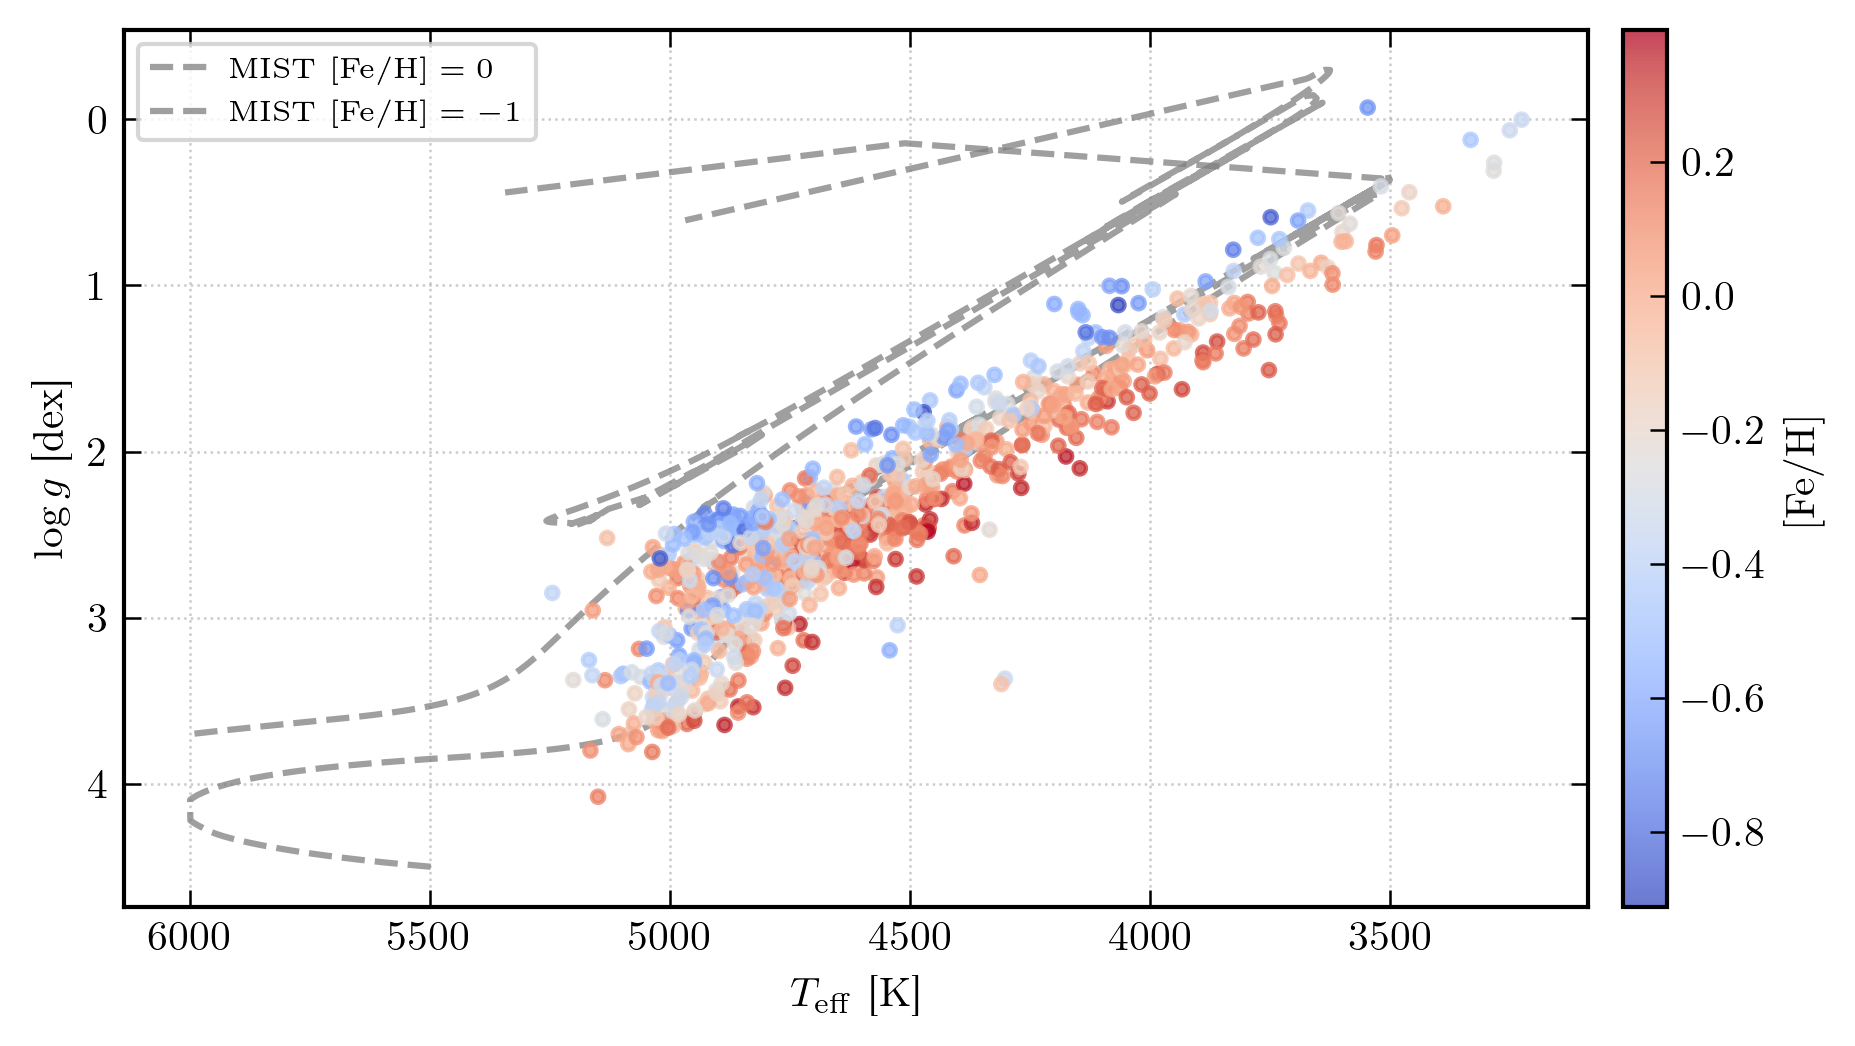

In [11]:
isochrone_tracks = [
    (r"MIST $[\mathrm{Fe/H}]=0$", iso_solar),
    (r"MIST $[\mathrm{Fe/H}]=-1$", iso_metal_poor),
]

ax = plotters.plot_kiel_diagram(fitted_labels, isochrone_tracks)
plt.show()

### Save cross-validation results

In [12]:
# Save CV results
np.savez_compressed(
    "cv_results.npz",
    fitted_labels=fitted_labels,
    true_labels=labels_cv,
    apogee_ids_cv=ids_cv,
)
print("Saved cv_results.npz")
print(f"  fitted_labels: {fitted_labels.shape}")
print(f"  true_labels: {labels_cv.shape}")

Saved cv_results.npz
  fitted_labels: (901, 5)
  true_labels: (901, 5)
